In [3]:
# This example shows how to generate an OLCR scan for a network
import numpy as np
from complex_network.networks.network_factory import generate_network
from complex_network.interferometry.olcr import OLCR
from complex_network.networks.network_spec import NetworkSpec

# generates a fingerprint that can be used to cache the OLCR response of a network and save it
# Generates a fingerprint from the network spec
from complex_network.networks.network_path_search import _spec_fingerprint

In [ ]:
spec = NetworkSpec(
                    num_external_nodes=3,
                    num_internal_nodes=10,
                    network_type="delaunay",
                    network_shape="circular",
                    external_size=210e-6,
                    network_size=200e-6,
                    external_offset=10e-6,
                    random_seed=1,
                    fully_connected=True,
                    node_S_mat_type='neumann'
                )

# Generate network
network = generate_network(spec)
fingerprint = _spec_fingerprint(spec)

# Configuration parameters
wavelength_sampling = int(1e6)     # The number of points along the wavelength axis to sample for the OLCR response (More better-but slower)
max_opl = 5000e-6                  # The maximum OPL to sample for the OLCR response 
max_length_sampling = int(1e5)     # The number of points along the length axis to sample for the OLCR response (More better-but slower)
use_mp = True                      # Whether to use multiprocessing to speed up the OLCR response calculation (Recommended for large networks and high sampling rates)                     

In [ ]:
olcr = OLCR(
        network=network,
        input_node=0,                              # Illuminating port
        measurement_node=0,                        # Measurement port
        central_wavelength=1000e-9,                # Central wavelength of the broadband source
        bandwidth=400e-9,                          # Bandwidth of the source, determines the resolution of the OLCR response
        integeration_method='czt',                 # Using the CZT method, usually faster than the euler method
        num_wavelength_sample=wavelength_sampling,
        optical_path_length=[0, max_opl],
        num_optical_path_length_sample=max_length_sampling,
        use_multi_proc=use_mp
    )

In [ ]:
# Get the OLCR response of the network
olcr.get_interferogram()

Calculating interferogram (FT Method) parallelly


array([0.85525997, 0.85526501, 0.8552898 , ..., 0.85785404, 0.85555237,
       0.85345795])

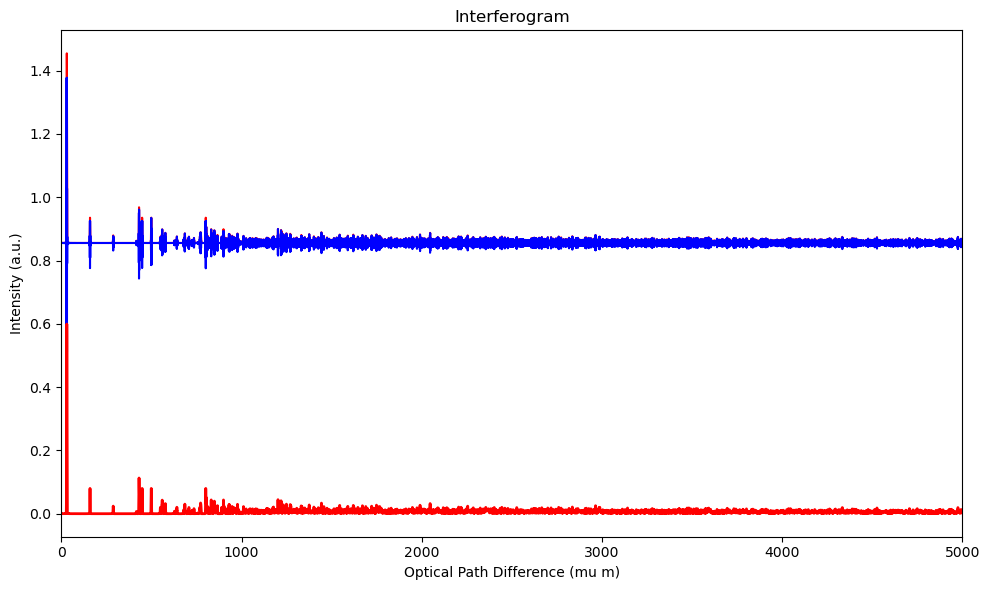

In [ ]:
# plot the OLCR response (A bug here, the envelope is usually generated by removing the DC part)
olcr.plot_interferogram(plot_signal=True, plot_envelope=True)